<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이미지를 읽어왔습니다.
shape = (889, 889)


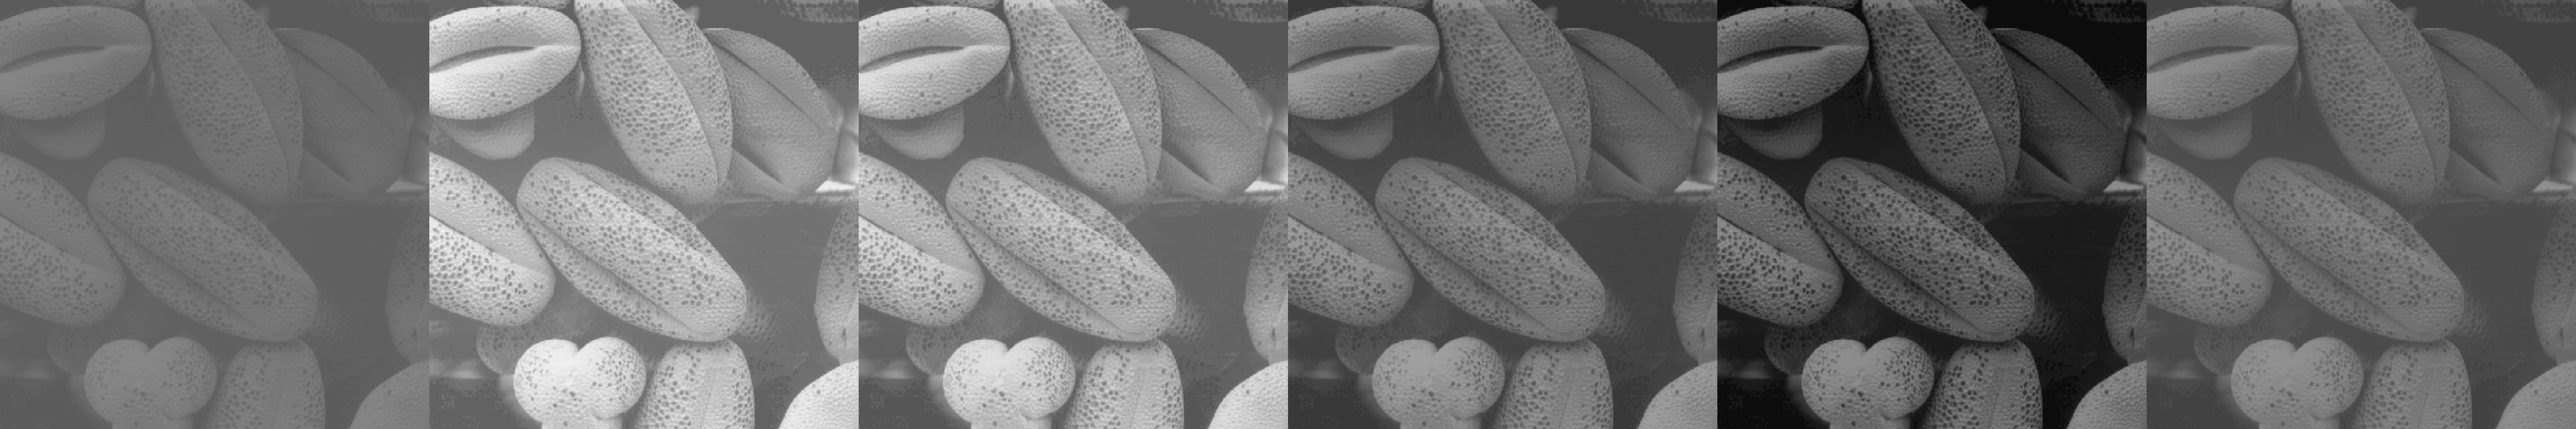

In [19]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Fig0310(b)(washed_out_pollen_image).tif', cv2.IMREAD_GRAYSCALE)

if img is not None:
    print("이미지를 읽어왔습니다.")
else:
    print("이미지를 읽어오지 못했습니다.")

print("shape =", img.shape)


def piecewise_linear(f, r1, s1, r2, s2):
    f = f.astype(np.float32)
    g = np.zeros_like(f)

    # 1구간: 0 <= r <= r1
    mask1 = (f <= r1)
    if r1 != 0:
        g[mask1] = (s1 / r1) * f[mask1]
    else:
        g[mask1] = 0

    # 2구간: r1 < r < r2
    mask2 = (f > r1) & (f < r2)
    g[mask2] = ((s2 - s1) / (r2 - r1)) * (f[mask2] - r1) + s1

    # 3구간: r2 <= r <= 255
    mask3 = (f >= r2)
    if r2 != 255:
        g[mask3] = ((255 - s2) / (255 - r2)) * (f[mask3] - r2) + s2
    else:
        g[mask3] = 255

    return np.uint8(np.clip(g, 0, 255))

g1 = piecewise_linear(img, 60, 0, 140, 255)
g2 = piecewise_linear(img, 70, 20, 140, 240)
g3 = piecewise_linear(img, 80, 30, 160, 220)
g4 = piecewise_linear(img, 90, 10, 170, 245)
g5 = piecewise_linear(img, 60, 10, 190, 245)



gc = np.hstack((img, g1, g2, g3, g4, g5))
cv2_imshow(gc)